## 0) Importing packages

In [1]:
import jax
import jax.numpy as jnp
import time
import optax
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
import ot
import ot as pot
import torchdyn
from ott.neural.networks import icnn
from ott.neural.methods import neuraldual
from sklearn.datasets import make_blobs
from typing import Any, Callable, Sequence, Tuple
import flax.linen as nn
from jax import jit
from functools import partial

## 1) Generating synthetic data

In [18]:
X_np, _ = make_blobs(n_samples=500, n_features=2, centers=[[5, 0]], random_state=42)
Y_np, _ = make_blobs(n_samples=500, n_features=2, centers=[[10, 10], [0, 10]], random_state=43)

# Converting to Jax array
X = jnp.array(X_np)
Y = jnp.array(Y_np)

class SimpleDataLoader:
    def __init__(self, data, batch_size):
        self.data = data
        self.batch_size = batch_size
        self.num_samples = data.shape[0]
    
    def __iter__(self):
        while True:
            idx = jax.random.choice(jax.random.PRNGKey(int(time.time() * 1e6) % 2**32), 
                                    self.num_samples, 
                                    shape=(self.batch_size,), 
                                    replace=False)
            yield self.data[idx]

train_batch_size = 500
train_dataloaders = (iter(SimpleDataLoader(X, train_batch_size)),
                     iter(SimpleDataLoader(Y, train_batch_size)))

valid_dataloaders = (iter(SimpleDataLoader(X, train_batch_size)),
                     iter(SimpleDataLoader(Y, train_batch_size)))

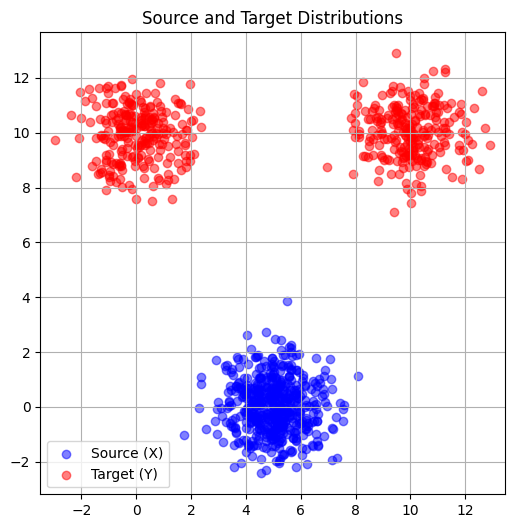

In [19]:
X_np = jnp.array(X).to_py() if hasattr(X, 'to_py') else jnp.array(X)
Y_np = jnp.array(Y).to_py() if hasattr(Y, 'to_py') else jnp.array(Y)

# Plot
plt.figure(figsize=(6, 6))
plt.scatter(X_np[:, 0], X_np[:, 1], color='blue', alpha=0.5, label='Source (X)')
plt.scatter(Y_np[:, 0], Y_np[:, 1], color='red', alpha=0.5, label='Target (Y)')
plt.title("Source and Target Distributions")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.show()

## 2) ICNN implementation

In [21]:
PRNGKey = Any
Shape = Tuple[int]
Dtype = Any
Array = Any

class PositiveDense(nn.Module):
    dim_hidden: int
    beta: int = 30.0
    kernel_init: Callable[[PRNGKey, Shape, Dtype], Array] = nn.initializers.lecun_normal()

    @nn.compact
    def __call__(self, inputs):
        x = inputs
        kernel = self.param('kernel', self.kernel_init, (inputs.shape[-1], self.dim_hidden))
        kernel = 1/self.beta * nn.softplus( self.beta * kernel)
        x = jax.lax.dot_general(inputs, kernel, (((inputs.ndim - 1,), (0,)), ((), ())))
        return x
    

class ICNN(nn.Module):
  dim_hidden: Sequence[int]
  act_fn: Callable = nn.elu
  init_fn: Callable = nn.initializers.variance_scaling(scale=1., distribution="normal", mode="fan_avg")

  def setup(self):
    self.dim = self.dim_hidden + (1,)
    self.w_zs = [PositiveDense(feature, kernel_init=self.init_fn) for feature in self.dim]
    self.w_ys = [nn.Dense(feature, use_bias=True, kernel_init=self.init_fn) for feature in self.dim]

  @nn.compact
  def __call__(self, input):
    y = input
    z = jnp.zeros(shape=y.shape)
    for w_z, w_y in zip(self.w_zs[:-1], self.w_ys[:-1]):
      z = self.act_fn(w_z(z) + w_y(y))
    z = self.w_zs[-1](z) + self.w_ys[-1](y)
    return z.squeeze()

class sampler_from_data:
    def __init__(self, x ):
        self.x = x
        self.setup()

    def setup(self):
        @partial(jit, static_argnums=1)
        def generate_samples(key, num_samples):
            points = jax.random.choice(key, self.x, (num_samples,))
            return points

        # define samples generator
        self.generate_samples = generate_samples

In [22]:
def training_callback(step, learned_potentials):
    # Callback function as the training progresses to visualize the couplings.
    if step % 1000 == 0:
        clear_output()
        print(f"Training iteration: {step}/{num_train_iters}")

        fig, ax = learned_potentials.plot_ot_map(
            X_new,
            Y_new,
            forward=True,
        )
        display(fig)
        plt.close(fig)

        fig, ax = learned_potentials.plot_ot_map(
            X_new,
            Y_new,
            forward=False,
        )
        display(fig)
        plt.close(fig)

        fig, ax = learned_potentials.plot_potential()
        display(fig)
        plt.close(fig)

In [23]:
# initialize optimizers
optimizer_f = optax.adam(learning_rate=1e-4, b1=0.5, b2=0.9, eps=1e-8)
optimizer_g = optax.adam(learning_rate=1e-4, b1=0.5, b2=0.9, eps=1e-8)

# initialize models using identity initialization (default)
neural_f = icnn.ICNN(dim_hidden=[64, 64, 64, 64], dim_data=2)
neural_g = icnn.ICNN(dim_hidden=[64, 64, 64, 64], dim_data=2)

# Select the Neural Dual solver
num_train_iters = 1000

neural_dual_solver = neuraldual.W2NeuralDual(
    2,
    neural_f,
    neural_g,
    optimizer_f,
    optimizer_g,
    num_train_iters = num_train_iters
)

learned_potentials_identity = neural_dual_solver(*train_dataloaders, *valid_dataloaders, callback=training_callback)
clear_output()

# Solve forward problem X -> Y
## Plot f potential
learned_potentials_identity.plot_potential(forward=True)
plt.show()

## Plot OT map
learned_potentials_identity.plot_ot_map(X_new, Y_new, forward=True)
plt.title("Forward: X -> Y")
plt.show()

transported_samples_forward = learned_potentials_identity.transport(X_new, forward = True)

## Compute Sinkhorn distance
sinkhorn_div_neural_forward = sinkhorn_loss(transported_samples_forward, Y_new)
print(
    f"Sinkhorn distance between target predictions and data samples: {sinkhorn_div_neural_forward:.2f}"
)
# Compute overall distance
neural_dual_dist = learned_potentials_identity.distance(X_new, Y_new)
print(
    f"Neural dual distance between source and target data: {neural_dual_dist:.2f}")



Training iteration: 0/1000


NameError: name 'X_new' is not defined